Loaded data:
  upgrade_cohort     : (15684, 79)
  risky_upgrade      : 1,308
  safe_upgrade       : 14,376
  Baseline DR        : 8.34%
  NB03 variables     : 58
  NB04 rules         : 491
  Financial features : 64

LAYER 1 — Single-Variable Warning Factors

FDR-significant variables (q < 0.05): 50
Layer 1 factors registered : 50
  Risk-reducing (OR < 1)   : 43
  Risk-increasing (OR > 1) : 7
Saved: ../results/tables/NB06_L1_single_factors.csv

Layer 1 factor list:
ID       Variable                                OR      q-val Trigger
--------------------------------------------------------------------------------
L1-01    Attr26                               0.629   7.06e-12  LOW (bottom 33%)
L1-02    Attr16                               0.630   2.77e-11  LOW (bottom 33%)
L1-03    total_liabilities_to_assets          1.368   0.00e+00  HIGH (top 33%)
L1-04    Attr51                               1.366   0.00e+00  HIGH (top 33%)
L1-05    Attr35                               0.646   0.00e

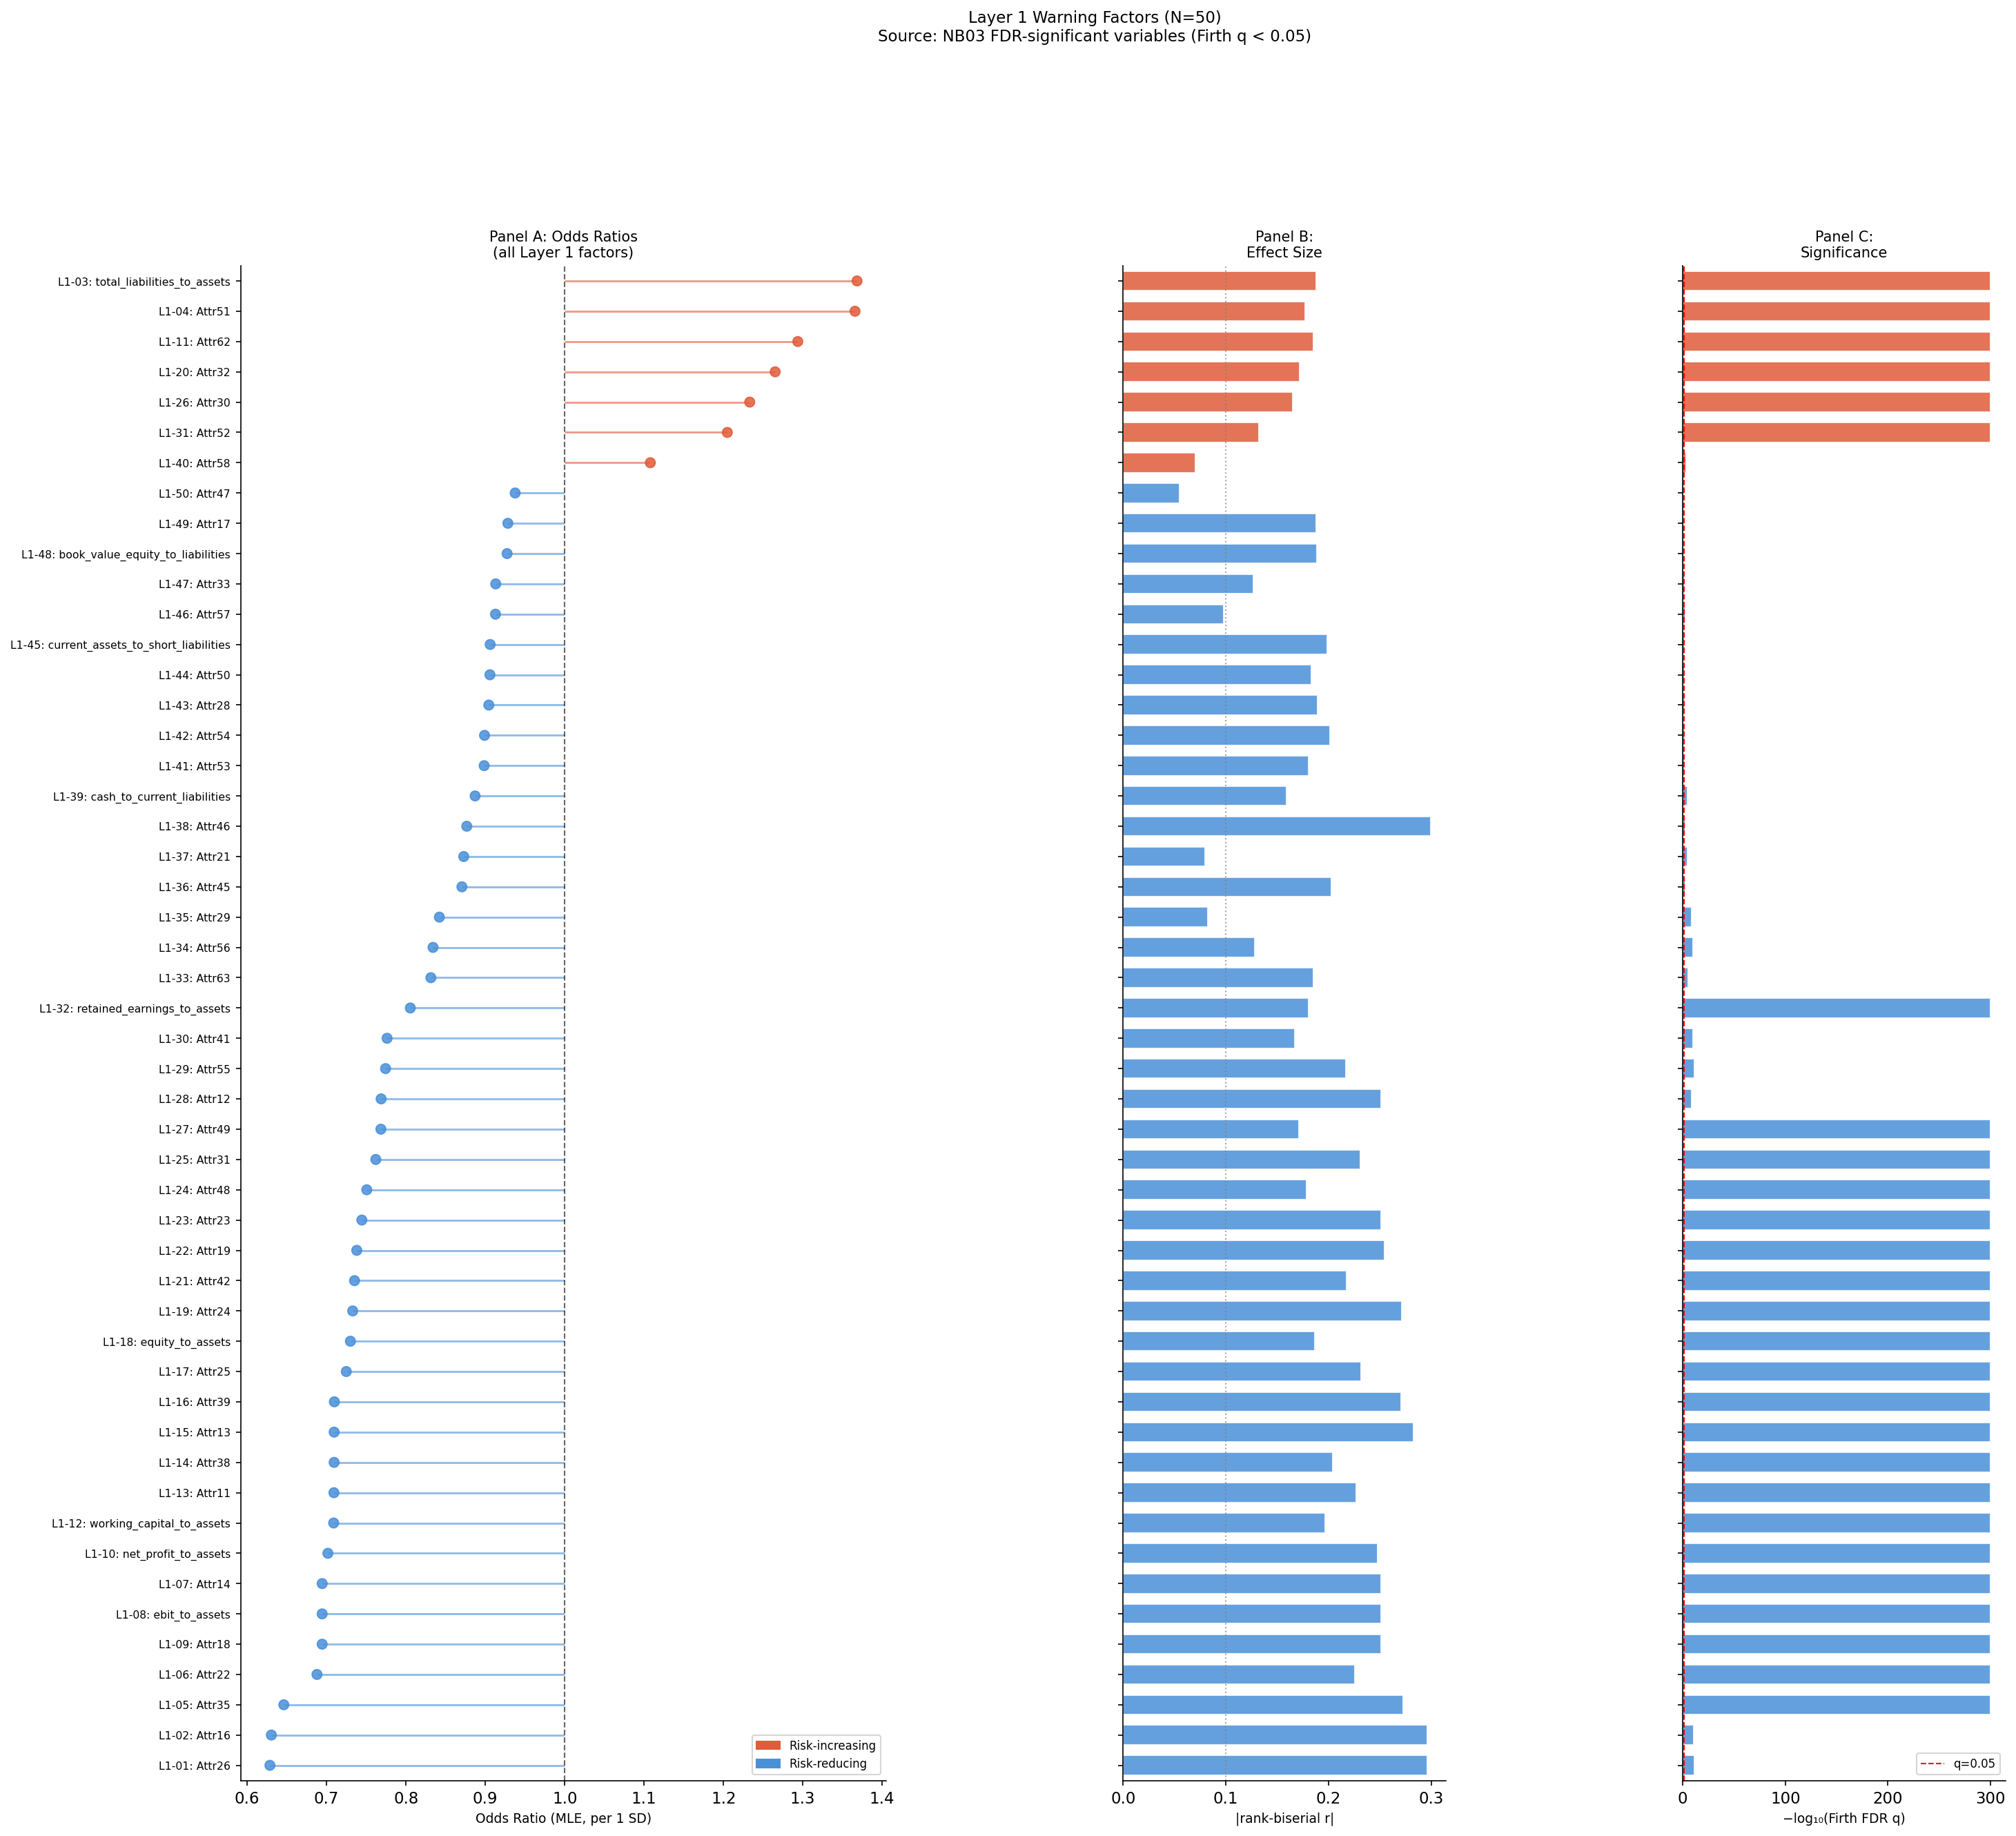

Figure saved: NB06_01_L1_factor_overview.png

[Figure 2] Layer 2 composite factor overview


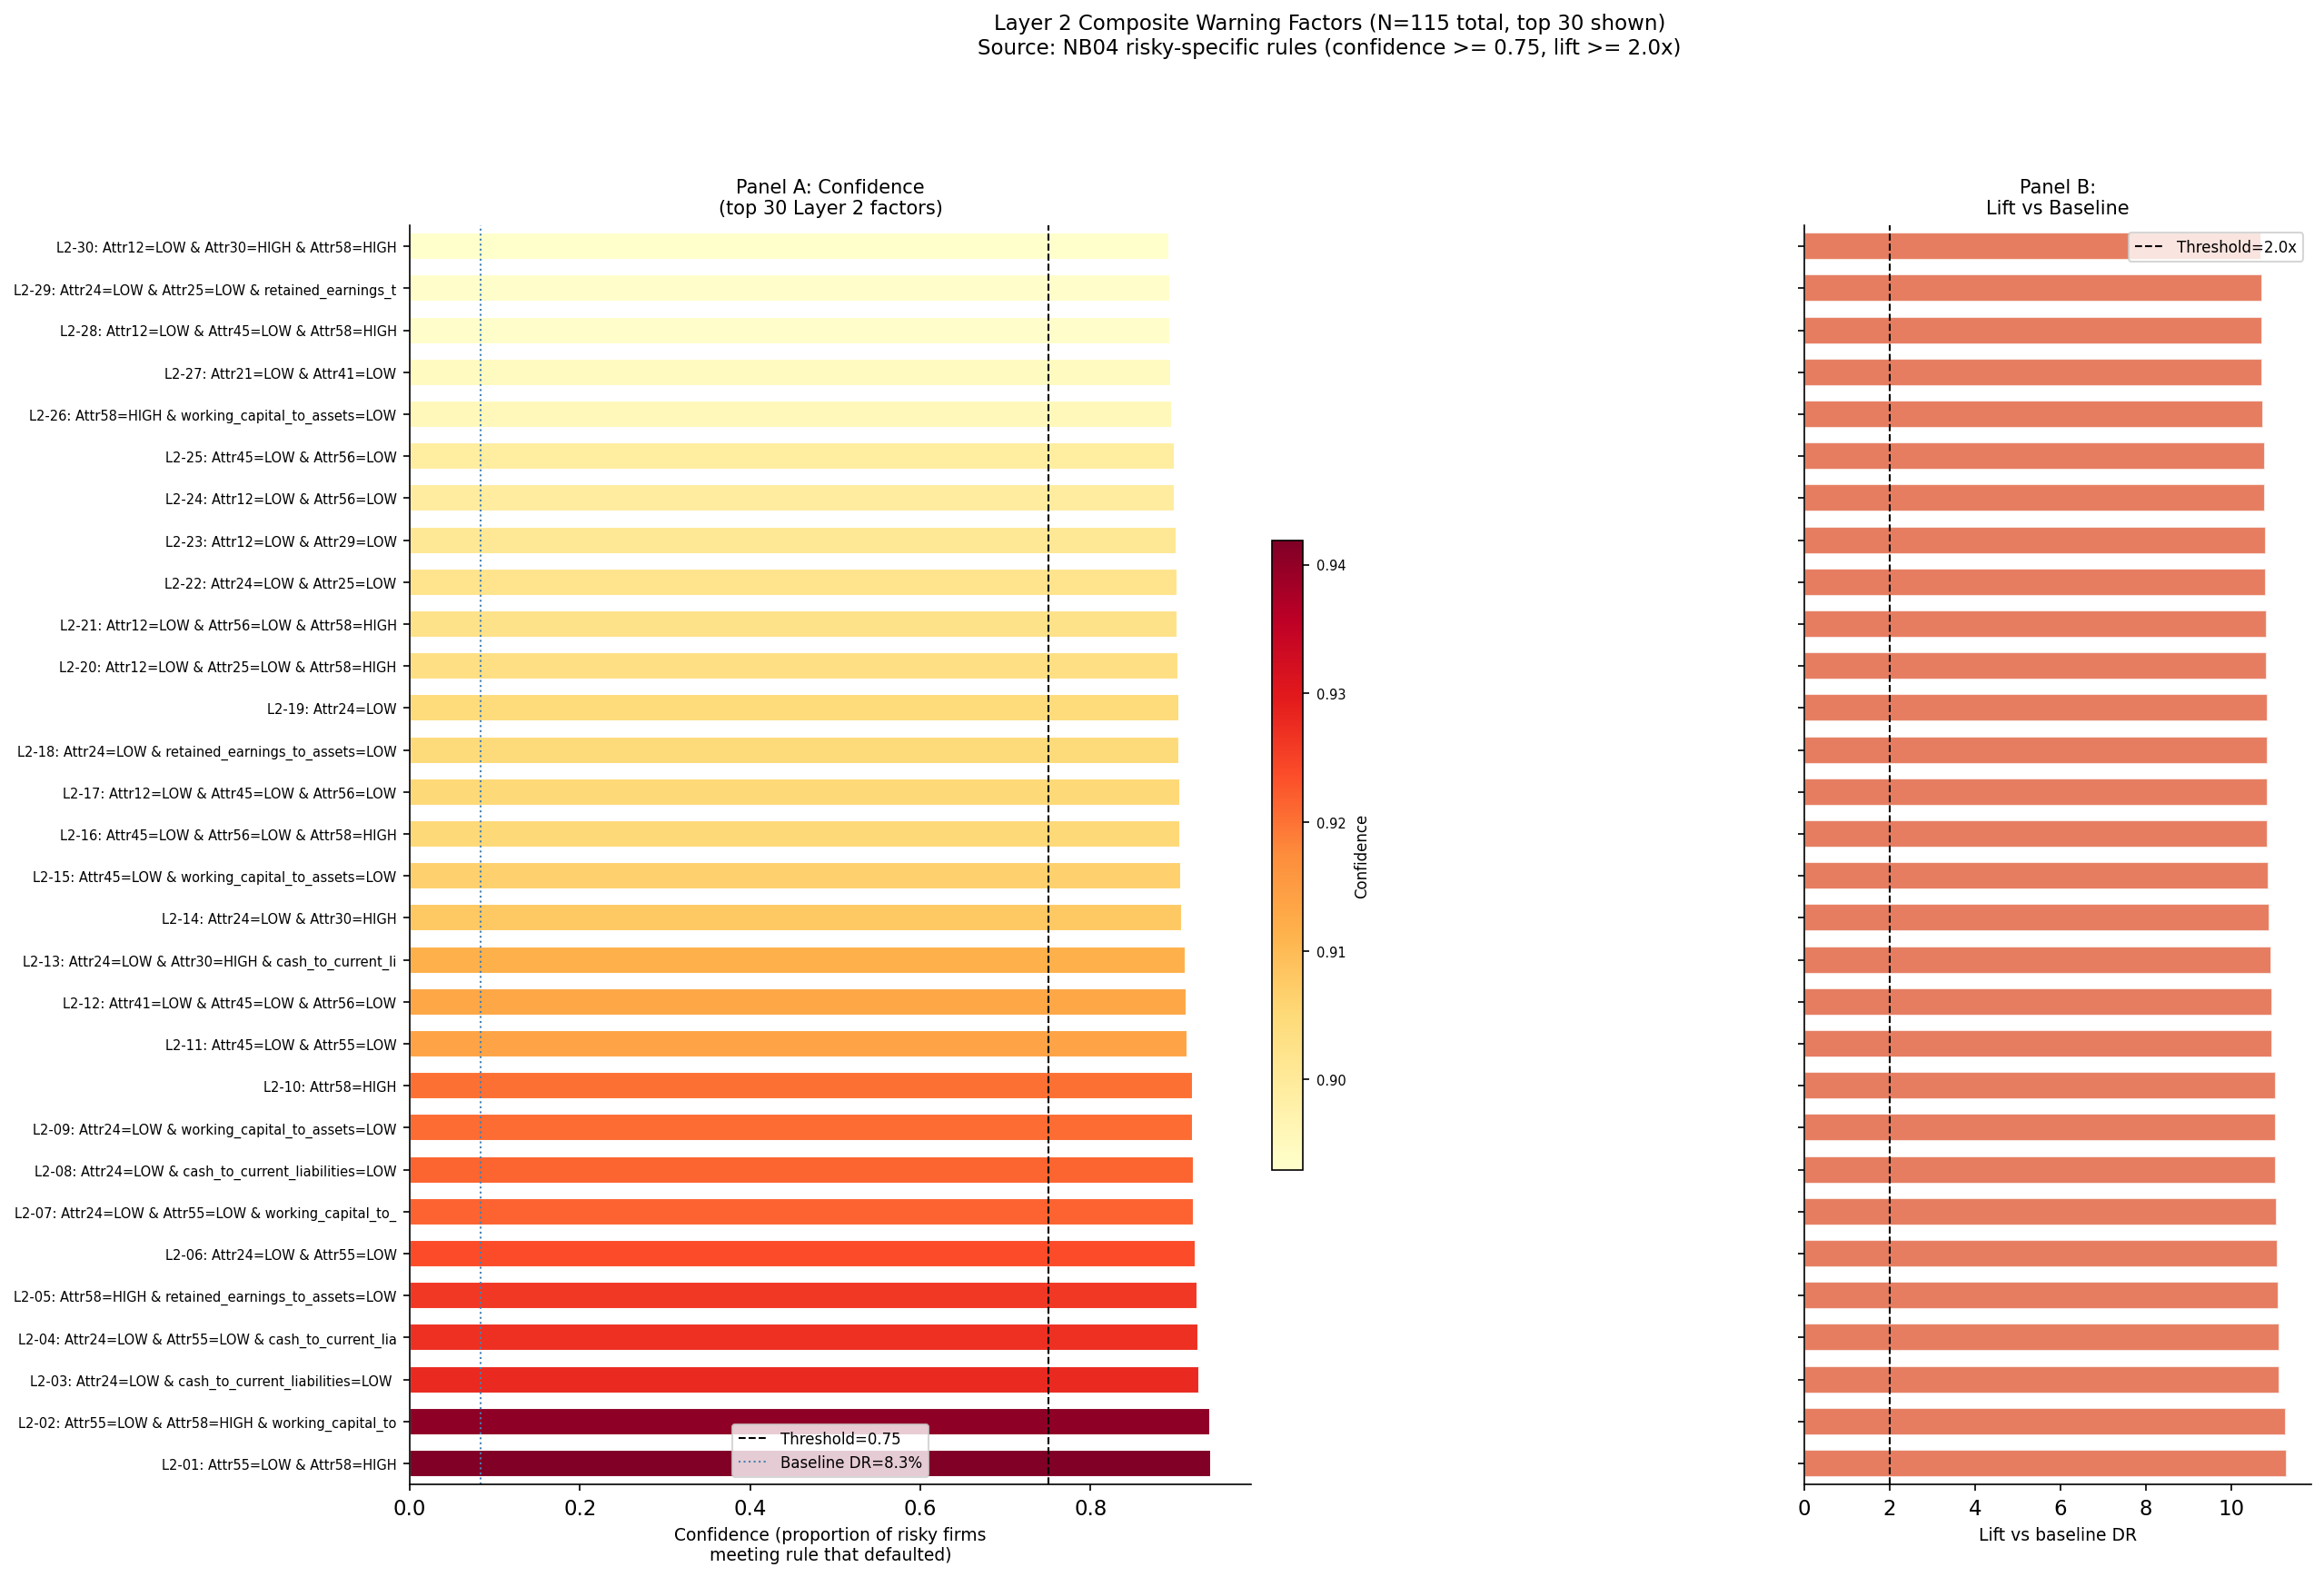

Figure saved: NB06_02_L2_composite_overview.png

[Step] Saving warning system design specification as CSV...
Saved: ../results/tables/NB06_03_system_design_spec.csv
  Rows: 23
  Categories: ['Process flow', 'L1 design', 'L2 design', 'System parameters']

System design spec preview:

  [Process flow]  (7 rows)
    1: Input
    2: Data retrieval
    3: Layer 1 check
    4: Layer 2 check
    5: Warning display
    6: No warning
    7: Evaluator decision

  [L1 design]  (5 rows)
    L1-P1: Layer 1 — factor source
    L1-P2: Layer 1 — inclusion criterion
    L1-P3: Layer 1 — factor count
    L1-P4: Layer 1 — trigger threshold
    L1-P5: Layer 1 — OR range

  [L2 design]  (6 rows)
    L2-P1: Layer 2 — factor source
    L2-P2: Layer 2 — inclusion criteria
    L2-P3: Layer 2 — factor count
    L2-P4: Layer 2 — confidence range
    L2-P5: Layer 2 — lift range
    L2-P6: Layer 2 — variable discretisation

  [System parameters]  (5 rows)
    SYS-1: Warning mode
    SYS-2: Audit trail
    SYS-3: F

In [6]:
# NB06_judgment_factors.ipynb
# Study 2: Synthesising a comprehensive early-warning factor library
#
# Design philosophy:
#   Rather than selecting a small number of "best" factors, this notebook
#   constructs a comprehensive library of warning factors that can be
#   pre-loaded into a credit rating system. When an evaluator proposes an
#   upgrade override, the system checks the firm's financial data against
#   all registered factors and displays any matches as warnings.
#
#   Two-layer factor architecture:
#
#   Layer 1 — Single-variable warning factors
#     Source  : NB03 FDR-significant variables (up to 50 factors)
#     Trigger : firm value falls in distress tertile (bottom 33% for
#               risk-reducing variables; top 33% for risk-increasing)
#     Rationale: each variable individually predicts post-upgrade default
#                at a statistically significant level (Firth FDR q < 0.05)
#
#   Layer 2 — Composite warning factors (multi-variable patterns)
#     Source  : NB04 risky-specific association rules (confidence >= 0.75)
#     Trigger : firm simultaneously satisfies all antecedent conditions
#     Rationale: co-occurring distress signals amplify default risk beyond
#                what any single variable captures
#
# Input  : data/processed/upgrade_cohort.parquet
#           results/tables/NB03_01_univariate_logistic.csv
#           results/tables/NB03b_variable_map.csv
#           results/tables/NB04_02_rules_summary.csv
#           results/tables/NB05_01_cluster_profiles.csv
# Outputs:
#   results/tables/NB06_L1_single_factors.csv
#   results/tables/NB06_L2_composite_factors.csv
#   results/tables/NB06_full_factor_library.csv
#   results/figures/NB06_01_L1_factor_overview.png
#   results/figures/NB06_02_L2_composite_overview.png
#   results/figures/NB06_03_warning_system_design.png

import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

warnings.filterwarnings("ignore")

plt.rcParams.update({
    "figure.dpi"       : 150,
    "axes.spines.top"  : False,
    "axes.spines.right": False,
    "font.size"        : 11,
    "font.family"      : "DejaVu Sans",
})

PROC_DIR  = "../data/processed/"
FIG_DIR   = "../results/figures/"
TABLE_DIR = "../results/tables/"

os.makedirs(FIG_DIR,   exist_ok=True)
os.makedirs(TABLE_DIR, exist_ok=True)

# ── Layer thresholds ──────────────────────────────────────────────────────────
L1_FDR_THRESHOLD  = 0.05    # Firth FDR q < 0.05 for Layer 1 inclusion
L2_CONF_THRESHOLD = 0.75    # association rule confidence >= 0.75 for Layer 2
L2_LIFT_THRESHOLD = 2.0     # lift vs baseline >= 2.0 for Layer 2


# ── Load data ─────────────────────────────────────────────────────────────────

cohort      = pd.read_parquet(PROC_DIR + "upgrade_cohort.parquet")
lr_df       = pd.read_csv(TABLE_DIR + "NB03_01_univariate_logistic.csv", index_col=0)
var_map     = pd.read_csv(TABLE_DIR + "NB03b_variable_map.csv", index_col=0)
rules_df    = pd.read_csv(TABLE_DIR + "NB04_02_rules_summary.csv")
profiles_df = pd.read_csv(TABLE_DIR + "NB05_01_cluster_profiles.csv", index_col=0)

risky = cohort[cohort["group"] == "risky_upgrade"]
safe  = cohort[cohort["group"] == "safe_upgrade"]

BASELINE_DR = cohort["default"].mean()

# All financial feature columns (exclude metadata)
EXCLUDE = {
    "default", "year_horizon", "class", "pd_system", "grade_ordinal",
    "grade_diff", "override_flag", "final_grade_ordinal", "system_grade",
    "group", "is_risky", "from_grade", "to_grade", "transition",
    "high_risk_transition", "cluster",
}
all_fin_cols = [c for c in cohort.columns
                if c not in EXCLUDE
                and cohort[c].dtype in [np.float64, np.int64, float, int]]

print(f"Loaded data:")
print(f"  upgrade_cohort     : {cohort.shape}")
print(f"  risky_upgrade      : {len(risky):,}")
print(f"  safe_upgrade       : {len(safe):,}")
print(f"  Baseline DR        : {BASELINE_DR*100:.2f}%")
print(f"  NB03 variables     : {len(lr_df)}")
print(f"  NB04 rules         : {len(rules_df)}")
print(f"  Financial features : {len(all_fin_cols)}")


# ══════════════════════════════════════════════════════════════════════════════
# LAYER 1 — Single-variable warning factors
# ══════════════════════════════════════════════════════════════════════════════

print("\n" + "=" * 65)
print("LAYER 1 — Single-Variable Warning Factors")
print("=" * 65)

# Inclusion criterion: Firth FDR q < L1_FDR_THRESHOLD
# All variables that individually predict post-upgrade default are included.
# No composite score threshold — breadth is preferred over selectivity.

L1_candidates = lr_df[lr_df["sig_firth_fdr"] == True].copy()
print(f"\nFDR-significant variables (q < {L1_FDR_THRESHOLD}): {len(L1_candidates)}")

L1_factors = []
factor_id  = 1

for var, row in L1_candidates.iterrows():
    # Skip if variable not in cohort
    if var not in cohort.columns:
        continue

    vals     = cohort[var].dropna()
    p33      = vals.quantile(0.33)
    p67      = vals.quantile(0.67)
    direction = row["direction"]

    # Distress tertile definition
    if direction == "risk-reducing":
        trigger_bin   = "LOW"
        trigger_cond  = f"<= {p33:.4f}"
        trigger_pct   = "bottom 33%"
    else:
        trigger_bin   = "HIGH"
        trigger_cond  = f">= {p67:.4f}"
        trigger_pct   = "top 33%"

    # Empirical default rates in distress vs non-distress tertile
    if direction == "risk-reducing":
        distress_mask = cohort[var] <= p33
    else:
        distress_mask = cohort[var] >= p67

    dr_distress    = cohort.loc[distress_mask & (cohort["group"] == "risky_upgrade"),
                                "default"].mean() if distress_mask.sum() > 0 else np.nan
    dr_non_distress = cohort.loc[~distress_mask & (cohort["group"] == "risky_upgrade"),
                                 "default"].mean() if (~distress_mask).sum() > 0 else np.nan

    # Definition from var_map if available, else from ATTR_MAP fallback
    if var in var_map.index and "definition" in var_map.columns:
        definition = var_map.loc[var, "definition"]
    else:
        definition = var

    # Existing code gap (from NB03b knowledge)
    CODE_GAP_MAP = {
        "working_capital_to_assets"          : "D07/D08",
        "Attr25"                             : "D03",
        "Attr24"                             : "D07",
        "Attr30"                             : "D02/D04",
        "Attr12"                             : "D02",
        "Attr55"                             : "D07/D04",
        "Attr41"                             : "D03",
        "retained_earnings_to_assets"        : "D07",
        "Attr56"                             : "D07",
        "Attr29"                             : "D06",
        "Attr45"                             : "D07",
        "Attr21"                             : "D01",
        "cash_to_current_liabilities"        : "D02",
        "Attr58"                             : "D01",
        "Attr57"                             : "D02",
        "Attr47"                             : "D02",
    }
    existing_gap = CODE_GAP_MAP.get(var, "Not mapped to existing code")

    L1_factors.append({
        "factor_id"        : f"L1-{factor_id:02d}",
        "layer"            : 1,
        "variable"         : var,
        "definition"       : definition,
        "direction"        : direction,
        "OR_mle"           : round(row["OR_mle"],    4),
        "OR_firth"         : round(row["OR_firth"],  4),
        "rank_biserial"    : round(row["rank_biserial"], 4),
        "firth_fdr_q"      : row["p_firth_fdr"],
        "trigger_bin"      : trigger_bin,
        "trigger_condition": trigger_cond,
        "trigger_pct"      : trigger_pct,
        "threshold_p33"    : round(p33, 4),
        "threshold_p67"    : round(p67, 4),
        "existing_code_gap": existing_gap,
        "risky_median"     : round(risky[var].median(), 4) if var in risky.columns else np.nan,
        "safe_median"      : round(safe[var].median(),  4) if var in safe.columns else np.nan,
    })
    factor_id += 1

L1_df = pd.DataFrame(L1_factors).set_index("factor_id")

out_path = TABLE_DIR + "NB06_L1_single_factors.csv"
L1_df.to_csv(out_path)
print(f"Layer 1 factors registered : {len(L1_df)}")
print(f"  Risk-reducing (OR < 1)   : {(L1_df['direction']=='risk-reducing').sum()}")
print(f"  Risk-increasing (OR > 1) : {(L1_df['direction']=='risk-increasing').sum()}")
print(f"Saved: {out_path}")

print(f"\nLayer 1 factor list:")
print(f"{'ID':<8} {'Variable':<35} {'OR':>6} {'q-val':>10} {'Trigger'}")
print("-" * 80)
for fid, row in L1_df.iterrows():
    q_str = f"{row['firth_fdr_q']:.2e}" if row['firth_fdr_q'] < 0.001 else f"{row['firth_fdr_q']:.4f}"
    print(f"{fid:<8} {row['variable']:<35} {row['OR_mle']:>6.3f} {q_str:>10}  "
          f"{row['trigger_bin']} ({row['trigger_pct']})")


# ══════════════════════════════════════════════════════════════════════════════
# LAYER 2 — Composite warning factors (association rules)
# ══════════════════════════════════════════════════════════════════════════════

print("\n" + "=" * 65)
print("LAYER 2 — Composite Warning Factors (Association Rules)")
print("=" * 65)

# Filter rules by confidence and lift thresholds
L2_rules = rules_df[
    (rules_df["confidence"]      >= L2_CONF_THRESHOLD) &
    (rules_df["lift_vs_baseline"] >= L2_LIFT_THRESHOLD)
].copy()

# Deduplicate: keep highest-confidence rule per unique antecedent
L2_rules = (L2_rules
            .sort_values("confidence", ascending=False)
            .drop_duplicates(subset=["antecedents_str"])
            .reset_index(drop=True))

print(f"\nRules meeting threshold (conf>={L2_CONF_THRESHOLD}, lift>={L2_LIFT_THRESHOLD}x): {len(L2_rules)}")

# Build Layer 2 factor records
L2_factors = []
for i, row in L2_rules.iterrows():
    # Parse antecedent conditions into human-readable form
    items      = row["antecedents_str"].split(" & ")
    conditions = []
    for item in items:
        parts = item.split("=")
        if len(parts) == 2:
            var_name, bin_val = parts[0].strip(), parts[1].strip()
            vals = cohort[var_name].dropna() if var_name in cohort.columns else pd.Series()
            if len(vals) > 0:
                p33 = vals.quantile(0.33)
                p67 = vals.quantile(0.67)
                if bin_val == "LOW":
                    cond = f"{var_name} <= {p33:.4f}"
                elif bin_val == "HIGH":
                    cond = f"{var_name} >= {p67:.4f}"
                else:
                    cond = f"{var_name} = {bin_val}"
            else:
                cond = item
            conditions.append(cond)

    L2_factors.append({
        "factor_id"         : f"L2-{i+1:02d}",
        "layer"             : 2,
        "antecedents_str"   : row["antecedents_str"],
        "consequents_str"   : row["consequents_str"],
        "n_conditions"      : len(items),
        "conditions_detail" : " AND ".join(conditions),
        "support"           : round(row["support"],           4),
        "confidence"        : round(row["confidence"],        4),
        "lift_vs_baseline"  : round(row["lift_vs_baseline"],  4),
        "conf_safe"         : round(row["conf_safe"],         4),
        "conf_diff"         : round(row["conf_diff"],         4),
        "trigger_description": (
            f"Firm simultaneously satisfies: {row['antecedents_str']}. "
            f"Among upgrade-overridden firms meeting this condition, "
            f"confidence={row['confidence']:.1%} "
            f"(vs {row['conf_safe']:.1%} in safe group). "
            f"Lift vs baseline = {row['lift_vs_baseline']:.1f}x."
        ),
    })

L2_df = pd.DataFrame(L2_factors).set_index("factor_id")

out_path = TABLE_DIR + "NB06_L2_composite_factors.csv"
L2_df.to_csv(out_path)
print(f"Layer 2 factors registered : {len(L2_df)}")
print(f"  1-condition rules        : {(L2_df['n_conditions']==1).sum()}")
print(f"  2-condition rules        : {(L2_df['n_conditions']==2).sum()}")
print(f"  3-condition rules        : {(L2_df['n_conditions']==3).sum()}")
print(f"Saved: {out_path}")

print(f"\nTop 20 Layer 2 factors:")
print(f"{'ID':<8} {'Antecedents':<50} {'Conf':>6} {'Lift':>6} {'CDiff':>6}")
print("-" * 80)
for fid, row in L2_df.head(20).iterrows():
    ant_short = row["antecedents_str"][:48]
    print(f"{fid:<8} {ant_short:<50} {row['confidence']:>6.3f} "
          f"{row['lift_vs_baseline']:>6.2f} {row['conf_diff']:>6.3f}")


# ══════════════════════════════════════════════════════════════════════════════
# Full factor library
# ══════════════════════════════════════════════════════════════════════════════

print("\n" + "=" * 65)
print("FULL FACTOR LIBRARY SUMMARY")
print("=" * 65)

# Combine L1 and L2 into one reference table
L1_export = L1_df[["layer", "variable", "definition", "direction",
                    "OR_mle", "rank_biserial", "firth_fdr_q",
                    "trigger_condition", "trigger_pct",
                    "existing_code_gap"]].copy()
L1_export["antecedents_str"]  = L1_export["variable"]
L1_export["confidence"]       = np.nan
L1_export["lift_vs_baseline"] = np.nan

L2_export = L2_df[["layer", "antecedents_str", "conditions_detail",
                    "confidence", "lift_vs_baseline", "conf_diff"]].copy()

full_library = pd.concat([L1_export, L2_export], axis=0, ignore_index=True)
full_library.index = (
    [f"L1-{i+1:02d}" for i in range(len(L1_export))] +
    [f"L2-{i+1:02d}" for i in range(len(L2_export))]
)

out_path = TABLE_DIR + "NB06_full_factor_library.csv"
full_library.to_csv(out_path)

print(f"\nTotal warning factors in library : {len(full_library)}")
print(f"  Layer 1 (single variable)      : {len(L1_df)}")
print(f"  Layer 2 (composite pattern)    : {len(L2_df)}")
print(f"Saved: {out_path}")


# ── Figure 1: Layer 1 overview ────────────────────────────────────────────────

print("\n[Figure 1] Layer 1 factor overview")

L1_sorted = L1_df.sort_values("OR_mle", ascending=True)
n_l1      = len(L1_sorted)

fig, axes = plt.subplots(1, 3, figsize=(22, max(8, n_l1 * 0.38)),
                         gridspec_kw={"width_ratios": [3, 1.5, 1.5],
                                      "wspace": 0.55})
ax_or, ax_rb, ax_q = axes

y_pos  = np.arange(n_l1)
colors = L1_sorted["direction"].map(
    {"risk-increasing": "#E05C3A", "risk-reducing": "#4A90D9"}
).values

# OR lollipop
ax_or.hlines(y_pos, L1_sorted["OR_mle"].values, 1.0,
             color=colors, linewidth=1.4, alpha=0.6)
ax_or.scatter(L1_sorted["OR_mle"], y_pos,
              c=colors, s=45, zorder=5, alpha=0.85)
ax_or.axvline(1.0, color="black", linestyle="--", linewidth=1, alpha=0.6)
ax_or.set_yticks(y_pos)
ax_or.set_yticklabels(
    [f"{fid}: {row['variable']}" for fid, row in L1_sorted.iterrows()],
    fontsize=7.5,
)
ax_or.set_ylim(-0.5, n_l1 - 0.5)
ax_or.set_xlabel("Odds Ratio (MLE, per 1 SD)", fontsize=9)
ax_or.set_title("Panel A: Odds Ratios\n(all Layer 1 factors)", fontsize=10)
red_p  = mpatches.Patch(color="#E05C3A", label="Risk-increasing")
blue_p = mpatches.Patch(color="#4A90D9", label="Risk-reducing")
ax_or.legend(handles=[red_p, blue_p], fontsize=8, loc="lower right")

# Rank-biserial bar
ax_rb.barh(y_pos, L1_sorted["rank_biserial"].abs(),
           color=colors, edgecolor="white", height=0.65, alpha=0.85)
ax_rb.set_yticks(y_pos)
ax_rb.set_yticklabels([])
ax_rb.set_ylim(-0.5, n_l1 - 0.5)
ax_rb.set_xlabel("|rank-biserial r|", fontsize=9)
ax_rb.set_title("Panel B:\nEffect Size", fontsize=10)
ax_rb.axvline(0.10, color="grey", linestyle=":", linewidth=1, alpha=0.7)

# -log10(FDR q) bar
L1_sorted["neg_log_q"] = -np.log10(L1_sorted["firth_fdr_q"].clip(lower=1e-300))
ax_q.barh(y_pos, L1_sorted["neg_log_q"],
          color=colors, edgecolor="white", height=0.65, alpha=0.85)
ax_q.set_yticks(y_pos)
ax_q.set_yticklabels([])
ax_q.set_ylim(-0.5, n_l1 - 0.5)
ax_q.set_xlabel("−log₁₀(Firth FDR q)", fontsize=9)
ax_q.set_title("Panel C:\nSignificance", fontsize=10)
ax_q.axvline(-np.log10(0.05), color="red", linestyle="--",
             linewidth=1, label="q=0.05")
ax_q.legend(fontsize=8)

plt.suptitle(
    f"Layer 1 Warning Factors (N={n_l1})\n"
    f"Source: NB03 FDR-significant variables (Firth q < {L1_FDR_THRESHOLD})",
    fontsize=11, y=1.01,
)
plt.savefig(FIG_DIR + "NB06_01_L1_factor_overview.png", bbox_inches="tight")
plt.show()
print("Figure saved: NB06_01_L1_factor_overview.png")


# ── Figure 2: Layer 2 overview ────────────────────────────────────────────────

print("\n[Figure 2] Layer 2 composite factor overview")

top_l2 = L2_df.head(30)
n_l2   = len(top_l2)

fig, axes = plt.subplots(1, 2, figsize=(18, max(7, n_l2 * 0.40)),
                         gridspec_kw={"width_ratios": [3, 1.5], "wspace": 0.50})
ax_conf, ax_lift = axes

y2     = np.arange(n_l2)
labels = [
    f"{fid}: " + row["antecedents_str"][:45]
    for fid, row in top_l2.iterrows()
]

norm_conf = plt.Normalize(top_l2["confidence"].min(), top_l2["confidence"].max())
bar_colors = plt.cm.YlOrRd(norm_conf(top_l2["confidence"].values))

ax_conf.barh(y2, top_l2["confidence"], color=bar_colors,
             edgecolor="white", height=0.65)
ax_conf.axvline(L2_CONF_THRESHOLD, color="black", linestyle="--",
                linewidth=1, label=f"Threshold={L2_CONF_THRESHOLD}")
ax_conf.axvline(BASELINE_DR, color="steelblue", linestyle=":",
                linewidth=1, label=f"Baseline DR={BASELINE_DR*100:.1f}%")
ax_conf.set_yticks(y2)
ax_conf.set_yticklabels(labels, fontsize=7)
ax_conf.set_ylim(-0.5, n_l2 - 0.5)
ax_conf.set_xlabel("Confidence (proportion of risky firms\nmeeting rule that defaulted)",
                   fontsize=9)
ax_conf.set_title(f"Panel A: Confidence\n(top {n_l2} Layer 2 factors)", fontsize=10)
ax_conf.legend(fontsize=8)

sm = plt.cm.ScalarMappable(cmap="YlOrRd", norm=norm_conf)
sm.set_array([])
cb = plt.colorbar(sm, ax=ax_conf, shrink=0.5, pad=0.02)
cb.set_label("Confidence", fontsize=8)
cb.ax.tick_params(labelsize=7)

ax_lift.barh(y2, top_l2["lift_vs_baseline"],
             color="#E05C3A", alpha=0.80, edgecolor="white", height=0.65)
ax_lift.axvline(L2_LIFT_THRESHOLD, color="black", linestyle="--",
                linewidth=1, label=f"Threshold={L2_LIFT_THRESHOLD}x")
ax_lift.set_yticks(y2)
ax_lift.set_yticklabels([])
ax_lift.set_ylim(-0.5, n_l2 - 0.5)
ax_lift.set_xlabel("Lift vs baseline DR", fontsize=9)
ax_lift.set_title("Panel B:\nLift vs Baseline", fontsize=10)
ax_lift.legend(fontsize=8)

plt.suptitle(
    f"Layer 2 Composite Warning Factors (N={len(L2_df)} total, top {n_l2} shown)\n"
    f"Source: NB04 risky-specific rules "
    f"(confidence >= {L2_CONF_THRESHOLD}, lift >= {L2_LIFT_THRESHOLD}x)",
    fontsize=11, y=1.01,
)
plt.savefig(FIG_DIR + "NB06_02_L2_composite_overview.png", bbox_inches="tight")
plt.show()
print("Figure saved: NB06_02_L2_composite_overview.png")


# ── System design spec — saved as CSV instead of figure ──────────────────────
# The warning system architecture is documented as a structured CSV spec
# that can be directly used for system implementation and paper description.

print("\n[Step] Saving warning system design specification as CSV...")

design_rows = []

# ── Process flow ──────────────────────────────────────────────────────────────
flow_steps = [
    {"step": 1, "component": "Input",
     "description": "Evaluator proposes an upgrade override (grade increase)",
     "trigger": "Evaluator action",
     "output": "Override request with firm ID and proposed grade"},
    {"step": 2, "component": "Data retrieval",
     "description": "System retrieves firm's latest financial data from database",
     "trigger": "Automatic on override input",
     "output": "Financial feature vector (64 variables)"},
    {"step": 3, "component": "Layer 1 check",
     "description": (
         f"System checks all {len(L1_df)} single-variable warning factors. "
         f"For each factor, firm value is compared to the distress tertile threshold. "
         f"Source: NB03 Firth logistic regression (FDR q < {L1_FDR_THRESHOLD}). "
         f"OR range: {L1_df['OR_mle'].min():.3f}–{L1_df['OR_mle'].max():.3f}."
     ),
     "trigger": "Firm value <= p33 (risk-reducing) or >= p67 (risk-increasing)",
     "output": f"List of triggered L1 factors (0 to {len(L1_df)} possible)"},
    {"step": 4, "component": "Layer 2 check",
     "description": (
         f"System checks all {len(L2_df)} composite-pattern warning factors. "
         f"For each rule, system verifies whether all antecedent conditions are met. "
         f"Source: NB04 risky-specific association rules "
         f"(confidence >= {L2_CONF_THRESHOLD}, lift >= {L2_LIFT_THRESHOLD}x). "
         f"Confidence range: {L2_df['confidence'].min():.3f}–{L2_df['confidence'].max():.3f}."
     ),
     "trigger": "Firm simultaneously satisfies all antecedent bin conditions",
     "output": f"List of triggered L2 rules (0 to {len(L2_df)} possible)"},
    {"step": 5, "component": "Warning display",
     "description": (
         "If any L1 or L2 factor is triggered, system displays warning to evaluator. "
         "L1 message format: '[Factor ID] [Variable] is in the [bottom/top] 33% "
         "(value=X, threshold=Y). Among upgrade-overridden firms with this condition, "
         "post-upgrade default rate is Z%.' "
         "L2 message format: '[Factor ID] Pattern [A=LOW & B=HIGH] detected. "
         "Confidence=Z% (vs W% in safe group). Lift=Nx vs baseline.'"
     ),
     "trigger": "One or more factors triggered in L1 or L2",
     "output": "Warning panel shown to evaluator before override is finalised"},
    {"step": 6, "component": "No warning",
     "description": "No factors triggered. Override proceeds without system intervention.",
     "trigger": "Zero factors triggered in both L1 and L2",
     "output": "Override finalised normally"},
    {"step": 7, "component": "Evaluator decision",
     "description": (
         "Evaluator reviews triggered warnings and decides to confirm or revise "
         "the upgrade. Warning is advisory — evaluator retains final authority. "
         "Override decision and triggered warning IDs are logged for audit."
     ),
     "trigger": "Evaluator action after reviewing warnings",
     "output": "Final grade recorded; warning response logged"},
]

for row in flow_steps:
    row["category"] = "Process flow"
    design_rows.append(row)

# ── Layer 1 design parameters ─────────────────────────────────────────────────
l1_params = [
    {"step": "L1-P1", "component": "Layer 1 — factor source",
     "description": "NB03 univariate Firth logistic regression on upgrade_cohort",
     "trigger": "—", "output": "—", "category": "L1 design"},
    {"step": "L1-P2", "component": "Layer 1 — inclusion criterion",
     "description": f"Firth penalised logistic regression FDR q < {L1_FDR_THRESHOLD} (Benjamini-Hochberg)",
     "trigger": "—", "output": "—", "category": "L1 design"},
    {"step": "L1-P3", "component": "Layer 1 — factor count",
     "description": f"N = {len(L1_df)} factors ({(L1_df['direction']=='risk-reducing').sum()} risk-reducing, "
                    f"{(L1_df['direction']=='risk-increasing').sum()} risk-increasing)",
     "trigger": "—", "output": "—", "category": "L1 design"},
    {"step": "L1-P4", "component": "Layer 1 — trigger threshold",
     "description": "Distress tertile: bottom 33% for risk-reducing variables (OR < 1); "
                    "top 33% for risk-increasing variables (OR > 1). "
                    "Thresholds computed on full upgrade_cohort (N=15,684).",
     "trigger": "—", "output": "—", "category": "L1 design"},
    {"step": "L1-P5", "component": "Layer 1 — OR range",
     "description": f"Minimum OR: {L1_df['OR_mle'].min():.4f} | Maximum OR: {L1_df['OR_mle'].max():.4f} | "
                    f"Median |rank-biserial|: {L1_df['rank_biserial'].abs().median():.4f}",
     "trigger": "—", "output": "—", "category": "L1 design"},
]
design_rows.extend(l1_params)

# ── Layer 2 design parameters ─────────────────────────────────────────────────
l2_params = [
    {"step": "L2-P1", "component": "Layer 2 — factor source",
     "description": "NB04 risky-specific association rules (Apriori on upgrade_cohort)",
     "trigger": "—", "output": "—", "category": "L2 design"},
    {"step": "L2-P2", "component": "Layer 2 — inclusion criteria",
     "description": f"confidence >= {L2_CONF_THRESHOLD} AND lift_vs_baseline >= {L2_LIFT_THRESHOLD}x AND "
                    f"safe antecedent present (conf_diff comparison valid) AND distress item in antecedent",
     "trigger": "—", "output": "—", "category": "L2 design"},
    {"step": "L2-P3", "component": "Layer 2 — factor count",
     "description": f"N = {len(L2_df)} composite rules "
                    f"(1-condition: {(L2_df['n_conditions']==1).sum()}, "
                    f"2-condition: {(L2_df['n_conditions']==2).sum()}, "
                    f"3-condition: {(L2_df['n_conditions']==3).sum()})",
     "trigger": "—", "output": "—", "category": "L2 design"},
    {"step": "L2-P4", "component": "Layer 2 — confidence range",
     "description": f"Min: {L2_df['confidence'].min():.4f} | Max: {L2_df['confidence'].max():.4f} | "
                    f"Mean: {L2_df['confidence'].mean():.4f}",
     "trigger": "—", "output": "—", "category": "L2 design"},
    {"step": "L2-P5", "component": "Layer 2 — lift range",
     "description": f"Min: {L2_df['lift_vs_baseline'].min():.2f}x | "
                    f"Max: {L2_df['lift_vs_baseline'].max():.2f}x | "
                    f"Mean: {L2_df['lift_vs_baseline'].mean():.2f}x",
     "trigger": "—", "output": "—", "category": "L2 design"},
    {"step": "L2-P6", "component": "Layer 2 — variable discretisation",
     "description": "Each variable binned into LOW/MID/HIGH using population tertiles (p33, p67) "
                    "computed on full upgrade_cohort. Thresholds stored in NB04 bin_log.",
     "trigger": "—", "output": "—", "category": "L2 design"},
]
design_rows.extend(l2_params)

# ── System-level parameters ───────────────────────────────────────────────────
sys_params = [
    {"step": "SYS-1", "component": "Warning mode",
     "description": "Advisory (non-blocking). Evaluator sees warnings but retains override authority. "
                    "System logs which factors were triggered and whether evaluator proceeded.",
     "trigger": "—", "output": "—", "category": "System parameters"},
    {"step": "SYS-2", "component": "Audit trail",
     "description": "Every override stores: firm ID, proposed grade, system grade, "
                    "triggered L1 factor IDs, triggered L2 rule IDs, evaluator decision, timestamp.",
     "trigger": "—", "output": "—", "category": "System parameters"},
    {"step": "SYS-3", "component": "Factor library update",
     "description": "Library is re-estimated annually using rolling 3-year override history. "
                    "Thresholds (p33, p67) and association rules are recalibrated each cycle.",
     "trigger": "—", "output": "—", "category": "System parameters"},
    {"step": "SYS-4", "component": "Total factors",
     "description": f"L1: {len(L1_df)} single-variable factors + L2: {len(L2_df)} composite rules = "
                    f"{len(L1_df)+len(L2_df)} total warning factors in library.",
     "trigger": "—", "output": "—", "category": "System parameters"},
    {"step": "SYS-5", "component": "Baseline default rate",
     "description": f"Post-upgrade default rate in calibration sample: {BASELINE_DR*100:.2f}% "
                    f"(N={len(cohort):,} upgrade-overridden firm-years). "
                    "Used as reference for lift calculation in L2 factor descriptions.",
     "trigger": "—", "output": "—", "category": "System parameters"},
]
design_rows.extend(sys_params)

# Save
design_df = pd.DataFrame(design_rows)[
    ["category", "step", "component", "description", "trigger", "output"]
]
out_path = TABLE_DIR + "NB06_03_system_design_spec.csv"
design_df.to_csv(out_path, index=False)

print(f"Saved: {out_path}")
print(f"  Rows: {len(design_df)}")
print(f"  Categories: {design_df['category'].unique().tolist()}")
print("\nSystem design spec preview:")
for cat in design_df["category"].unique():
    sub = design_df[design_df["category"] == cat]
    print(f"\n  [{cat}]  ({len(sub)} rows)")
    for _, row in sub.iterrows():
        print(f"    {row['step']}: {row['component']}")


# ── Final summary ─────────────────────────────────────────────────────────────

print("\n" + "=" * 65)
print("NB06 SUMMARY — TWO-LAYER WARNING FACTOR LIBRARY")
print("=" * 65)
print(f"\nTotal warning factors : {len(full_library)}")
print(f"  Layer 1 (single)    : {len(L1_df)}")
print(f"  Layer 2 (composite) : {len(L2_df)}")
print()
print(f"Layer 1 design:")
print(f"  Source     : NB03 Firth logistic regression")
print(f"  Criterion  : FDR q < {L1_FDR_THRESHOLD}")
print(f"  Trigger    : firm in distress tertile (bottom/top 33%)")
print(f"  OR range   : {L1_df['OR_mle'].min():.3f} – {L1_df['OR_mle'].max():.3f}")
print(f"  |rb| range : {L1_df['rank_biserial'].abs().min():.3f} – "
      f"{L1_df['rank_biserial'].abs().max():.3f}")
print()
print(f"Layer 2 design:")
print(f"  Source     : NB04 risky-specific association rules")
print(f"  Criterion  : confidence >= {L2_CONF_THRESHOLD}, lift >= {L2_LIFT_THRESHOLD}x")
print(f"  Conf range : {L2_df['confidence'].min():.3f} – {L2_df['confidence'].max():.3f}")
print(f"  Lift range : {L2_df['lift_vs_baseline'].min():.2f}x – "
      f"{L2_df['lift_vs_baseline'].max():.2f}x")
print()
print("Deployment note:")
print("  The factor library is pre-loaded into the credit rating system.")
print("  At the moment an evaluator inputs an upgrade override, the system")
print("  automatically checks all Layer 1 and Layer 2 conditions and")
print("  displays any triggered warnings. The evaluator retains final")
print("  decision authority; warnings are advisory.")
print()
print("Output files:")
print(f"  {TABLE_DIR}NB06_L1_single_factors.csv")
print(f"  {TABLE_DIR}NB06_L2_composite_factors.csv")
print(f"  {TABLE_DIR}NB06_full_factor_library.csv")